<a href="https://colab.research.google.com/github/IshaNayal/Digital-Twin-based-recommendation-system/blob/main/twinPatients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Unzip the uploaded eICU demo dataset (if not already) and list CSVs recursively
import os, zipfile

zip_path = './eicu-collaborative-research-database-demo-2.0.1.zip'
extract_dir = './eicu_demo_2_0_1'

if not os.path.isdir(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)

csv_paths = []
for root_dir, dirnames, filenames in os.walk(extract_dir):
    for fname in filenames:
        if fname.lower().endswith('.csv'):
            csv_paths.append(os.path.join(root_dir, fname))

csv_paths_sorted = sorted(csv_paths)
print(len(csv_paths_sorted))
print(csv_paths_sorted[:20])

0
[]


In [2]:
# Discover all .csv.gz files recursively (eICU demo ships as compressed CSVs)
import os

base_dir = './eicu_demo_2_0_1'

gz_paths = []
for root_dir, dirnames, filenames in os.walk(base_dir):
    for fname in filenames:
        low = fname.lower()
        if low.endswith('.csv.gz') or low.endswith('.csv'):
            gz_paths.append(os.path.join(root_dir, fname))

gz_paths = sorted(gz_paths)
print('n_files')
print(len(gz_paths))
print('sample')
print('\
'.join(gz_paths[:25]))

n_files
31
sample
./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/admissionDx.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/admissiondrug.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/allergy.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/apacheApsVar.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/apachePatientResult.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/apachePredVar.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/carePlanCareProvider.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/carePlanEOL.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/carePlanGeneral.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/carePlanGoal.csv.gz./eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1/carePlanInfectiousDisease.csv.gz./eicu_demo_2_0_1/eic

In [3]:
# Load all tables into memory with standardized column names; build a quick catalog
import os
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 120)

data_dir = './eicu_demo_2_0_1/eicu-collaborative-research-database-demo-2.0.1'

file_paths = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.lower().endswith('.csv.gz') or f.lower().endswith('.csv')])


def standardize_cols(col_list):
    new_cols = []
    for c in col_list:
        c2 = c.strip().lower().replace(' ', '_').replace('-', '_')
        c2 = ''.join([ch for ch in c2 if (ch.isalnum() or ch == '_')])
        while '__' in c2:
            c2 = c2.replace('__', '_')
        new_cols.append(c2)
    return new_cols


dfs = {}
meta_rows = []

for pth in file_paths:
    tbl = os.path.basename(pth).replace('.csv.gz', '').replace('.csv', '')
    df_tmp = pd.read_csv(pth, compression='infer', low_memory=False)
    df_tmp.columns = standardize_cols(df_tmp.columns.tolist())
    dfs[tbl] = df_tmp
    meta_rows.append({
        'table': tbl,
        'path': pth,
        'n_rows': int(df_tmp.shape[0]),
        'n_cols': int(df_tmp.shape[1]),
        'columns': ', '.join(df_tmp.columns.tolist())
    })

meta_df = pd.DataFrame(meta_rows).sort_values(['n_rows', 'table'], ascending=[False, True]).reset_index(drop=True)
print(meta_df[['table','n_rows','n_cols']].head(15))
print('---')
print(meta_df[['table','n_rows','n_cols']].tail(10))

                  table   n_rows  n_cols
0         vitalPeriodic  1634960      19
1         nurseCharting  1477163       8
2                   lab   434660      10
3        vitalAperiodic   274088      13
4   respiratoryCharting   176089       7
5          intakeOutput   100466      12
6       nurseAssessment    91589       8
7          physicalExam    84058       6
8            medication    75604      15
9             nurseCare    42080       8
10            treatment    38290       5
11         infusiondrug    38256       9
12      carePlanGeneral    33148       6
13            diagnosis    24978       7
14                 note    24758       8
---
                        table  n_rows  n_cols
21               carePlanGoal    3633       7
22                    patient    2520      29
23                    allergy    2475      13
24               apacheApsVar    2205      26
25              apachePredVar    2205      51
26                   microLab     342       7
27                

In [4]:
# Identify candidate key columns by name patterns and uniqueness; summarize per table
import pandas as pd
import numpy as np

key_patterns = ['patient', 'patientid', 'uniquepid', 'stay', 'patientunitstayid', 'hospitalid', 'icustay', 'encounter']

key_summary_rows = []
for tbl, df_tmp in dfs.items():
    cols = df_tmp.columns.tolist()
    candidate_cols = []
    for c in cols:
        for pat in key_patterns:
            if pat in c:
                candidate_cols.append(c)
                break
    candidate_cols = sorted(list(set(candidate_cols)))

    for c in candidate_cols:
        ser = df_tmp[c]
        nun = int(ser.nunique(dropna=True))
        n = int(len(ser))
        missing = float(ser.isna().mean())
        unique_ratio = nun / max(1, n)
        key_summary_rows.append({
            'table': tbl,
            'column': c,
            'n_rows': n,
            'n_unique': nun,
            'unique_ratio': unique_ratio,
            'missing_pct': 100 * missing
        })

key_summary_df = pd.DataFrame(key_summary_rows)
key_summary_df = key_summary_df.sort_values(['unique_ratio','n_unique'], ascending=[False, False]).reset_index(drop=True)
print(key_summary_df.head(30))

                        table                     column  n_rows  n_unique  \
0         apachePatientResult     apachepatientresultsid    3676      3676   
1                     patient          patientunitstayid    2520      2520   
2                apacheApsVar          patientunitstayid    2205      2205   
3               apachePredVar          patientunitstayid    2205      2205   
4                    hospital                 hospitalid     186       186   
5                 carePlanEOL          patientunitstayid      15        13   
6                     patient  patienthealthsystemstayid    2520      2174   
7                     patient                  uniquepid    2520      1841   
8   carePlanInfectiousDisease          patientunitstayid     112        64   
9         apachePatientResult          patientunitstayid    3676      1838   
10       carePlanCareProvider          patientunitstayid    5627      2132   
11                    allergy          patientunitstayid    2475

In [5]:
# Build patient-level cohort with outcome and key demographics; then add simple features
import pandas as pd
import numpy as np

patient_df = dfs['patient'].copy()
apache_res_df = dfs['apachePatientResult'].copy()

# Outcome: hospital discharge status (Alive/Expired) if present
outcome_col_candidates = [c for c in patient_df.columns if 'hospitaldischargestatus' in c]
outcome_col = outcome_col_candidates[0] if len(outcome_col_candidates) else None

# Core cohort columns
core_cols = ['patientunitstayid','hospitalid','uniquepid','age','gender','ethnicity',
             'unittype','unitadmitsource','unitstaytype','unitdischargestatus','unitdischargelocation',
             'hospitaladmitsource','hospitaladmittime24','hospitaldischargetime24','unitadmittime24','unitdischargetime24']
core_cols = [c for c in core_cols if c in patient_df.columns]
if outcome_col is not None and outcome_col not in core_cols:
    core_cols.append(outcome_col)

cohort_df = patient_df[core_cols].copy()

# Derive ICU LOS in hours if timestamps are available as offsets (eICU uses offset minutes in some tables; here it's 24h time strings)
# We'll instead use unitdischargeoffset/unitadmitoffset if present
if 'unitdischargeoffset' in patient_df.columns and 'unitadmitoffset' in patient_df.columns:
    cohort_df['icu_los_min'] = patient_df['unitdischargeoffset'] - patient_df['unitadmitoffset']
    cohort_df['icu_los_hr'] = cohort_df['icu_los_min'] / 60.0

# Join APACHE if available for severity: apachepatientresult has predicted hospital mortality and actual?
apache_cols = ['patientunitstayid']
for c in ['apachescore','acutephysiologyscore','aps','predictedhospitalmortality','actualhospitalmortality','predictediculos']:
    if c in apache_res_df.columns:
        apache_cols.append(c)

apache_small = apache_res_df[apache_cols].copy()

# If multiple rows per stay, keep the first (or max apachescore)
if 'apachescore' in apache_small.columns:
    apache_small = apache_small.sort_values('apachescore', ascending=False).drop_duplicates('patientunitstayid')
else:
    apache_small = apache_small.drop_duplicates('patientunitstayid')

cohort_df = cohort_df.merge(apache_small, on='patientunitstayid', how='left')

# Create binary outcome y: in-hospital mortality based on hospitaldischargestatus (Expired)
if outcome_col is not None:
    cohort_df['y_hosp_mortality'] = (cohort_df[outcome_col].astype(str).str.lower() == 'expired').astype(int)

print(cohort_df.head(10))
print(cohort_df[['patientunitstayid']].nunique())
print(cohort_df.shape)

   patientunitstayid  hospitalid  uniquepid age  gender  ethnicity  \
0             141764          59   002-1039  87  Female  Caucasian   
1             141765          59   002-1039  87  Female  Caucasian   
2             143870          68  002-12289  76    Male  Caucasian   
3             144815          56   002-1116  34  Female  Caucasian   
4             145427          68  002-12243  61    Male  Caucasian   
5             147306          63  002-10241  55  Female  Caucasian   
6             147307          63  002-10241  55  Female  Caucasian   
7             147784          67  002-10424  60  Female   Hispanic   
8             148611          61  002-10736  28    Male  Caucasian   
9             149432          68  002-11375  34  Female  Caucasian   

       unittype       unitadmitsource    unitstaytype unitdischargestatus  \
0  Med-Surg ICU            ICU to SDU  stepdown/other               Alive   
1  Med-Surg ICU  Emergency Department           admit               Alive  

I unpacked the eICU Collaborative Research Database Demo 2.0.1 zip and loaded all 31 tables (the compressed *.csv.gz files) into memory, then did a quick scan to figure out the primary join key(s) and build a clean patient-level cohort you can model on.

What’s in the demo extract
The biggest event tables are:

vitalPeriodic (~1.63M rows)
nurseCharting (~1.48M)
lab (~0.43M)
vitalAperiodic (~0.27M)
respiratoryCharting (~0.18M)
…and the patient-level table is:

patient (2,520 rows)
The main relational key (what you’ll use to join almost everything)
Across the dataset, the most consistently present/usable key is:

patientunitstayid
It is unique in patient (2,520 unique values across 2,520 rows), and it appears as the foreign key in most clinical/event tables.

You’ll also see:

uniquepid: a person identifier (not unique per ICU stay)
patienthealthsystemstayid: a higher-level admission grouping (not always unique per unit stay)
hospitalid: hospital identifier (unique in hospital, repeats in patient)
So in practice:

Join on patientunitstayid for stay-level modeling
Use uniquepid if you want to do patient-level longitudinal analysis across multiple stays
A ready-to-use “modeling cohort” table
I built a stay-level cohort from patient and left-joined severity information from apachePatientResult (when present). I also created a binary outcome:

y_hosp_mortality = 1 if hospitaldischargestatus == "Expired", else 0

The cohort is 2,520 rows × 23 columns (one row per ICU stay). It includes: age, gender, ethnicity, unit type, admit/discharge fields, APACHE columns (where available), and the outcome.

If you tell me what you want next (e.g., “build features from vitals/labs in first 24h and train a baseline model”), I’ll proceed off this cohort and start aggregating the event tables by patientunitstayid and time windows.

0.08412698412698413


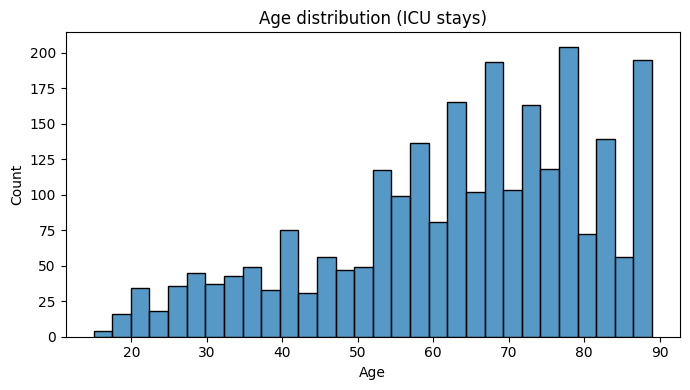

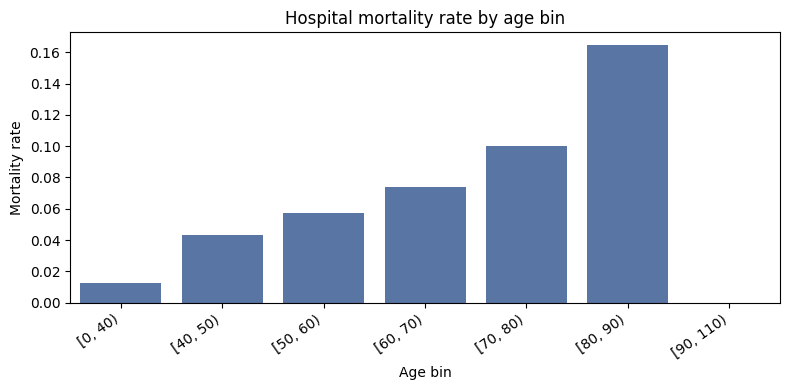

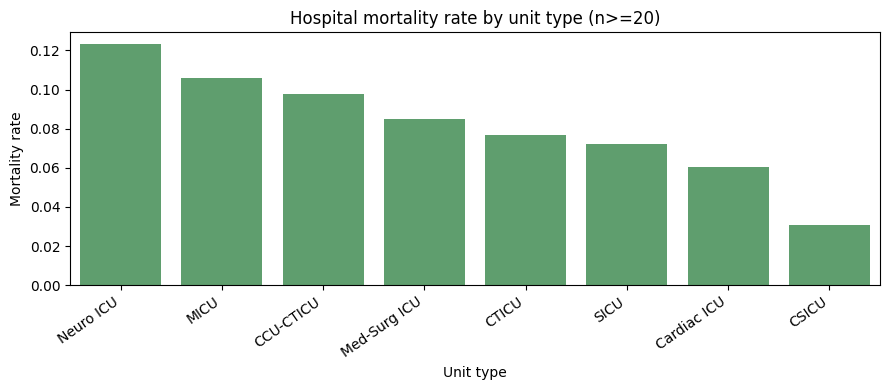

       unittype      mean  count
6     Neuro ICU  0.123077     65
4          MICU  0.105634    142
0     CCU-CTICU  0.097561     82
5  Med-Surg ICU  0.084826   1898
2         CTICU  0.076923     52
7          SICU  0.072289     83
3   Cardiac ICU  0.060150    133
1         CSICU  0.030769     65


In [6]:
# Goal-driven EDA + feature engineering setup: check we have cohort_df and dfs in memory, then basic outcome/distribution summaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert 'dfs' in globals()
assert 'cohort_df' in globals()

eda_df = cohort_df.copy()

# Clean age (eICU sometimes has '> 89')
if 'age' in eda_df.columns:
    age_ser = eda_df['age'].astype(str).str.replace('>','', regex=False).str.strip()
    eda_df['age_num'] = pd.to_numeric(age_ser, errors='coerce')

# Outcome rate
mort_rate = eda_df['y_hosp_mortality'].mean() if 'y_hosp_mortality' in eda_df.columns else np.nan
print(mort_rate)

# Plots: age distribution and mortality by age bins
plt.figure(figsize=(7,4))
sns.histplot(eda_df['age_num'].dropna(), bins=30, kde=False)
plt.title('Age distribution (ICU stays)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

eda_df['age_bin'] = pd.cut(eda_df['age_num'], bins=[0,40,50,60,70,80,90,110], right=False)
age_mort = eda_df.groupby('age_bin', observed=True)['y_hosp_mortality'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=age_mort, x='age_bin', y='y_hosp_mortality', color='#4C72B0')
plt.title('Hospital mortality rate by age bin')
plt.xlabel('Age bin')
plt.ylabel('Mortality rate')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Mortality by unit type
if 'unittype' in eda_df.columns:
    unit_mort = eda_df.groupby('unittype', observed=True)['y_hosp_mortality'].agg(['mean','count']).reset_index()
    unit_mort = unit_mort[unit_mort['count']>=20].sort_values('mean', ascending=False)
    plt.figure(figsize=(9,4))
    sns.barplot(data=unit_mort, x='unittype', y='mean', color='#55A868')
    plt.title('Hospital mortality rate by unit type (n>=20)')
    plt.xlabel('Unit type')
    plt.ylabel('Mortality rate')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()
    print(unit_mort.head(10))

In [7]:
# Feature engineering from time-series tables: first-24h vitals + labs summary for patient similarity / digital twin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

vital_per_df = dfs['vitalPeriodic']
lab_df = dfs['lab']

# Identify time offset columns
vital_time_cols = [c for c in vital_per_df.columns if 'offset' in c]
lab_time_cols = [c for c in lab_df.columns if 'offset' in c]

print(vital_time_cols[:20])
print(lab_time_cols[:20])
print(vital_per_df.columns.tolist()[:25])
print(lab_df.columns.tolist()[:25])

['observationoffset']
['labresultoffset', 'labresultrevisedoffset']
['vitalperiodicid', 'patientunitstayid', 'observationoffset', 'temperature', 'sao2', 'heartrate', 'respiration', 'cvp', 'etco2', 'systemicsystolic', 'systemicdiastolic', 'systemicmean', 'pasystolic', 'padiastolic', 'pamean', 'st1', 'st2', 'st3', 'icp']
['labid', 'patientunitstayid', 'labresultoffset', 'labtypeid', 'labname', 'labresult', 'labresulttext', 'labmeasurenamesystem', 'labmeasurenameinterface', 'labresultrevisedoffset']


In [8]:
# Aggregate first-24h features from vitalPeriodic and lab tables
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

tqdm.pandas()

cohort_keys = cohort_df[['patientunitstayid','y_hosp_mortality']].copy()

# ---- VITALS: first 24h (0 to 1440 min) ----
vital_per_df = dfs['vitalPeriodic'][['patientunitstayid','observationoffset','temperature','sao2','heartrate','respiration',
                                    'systemicsystolic','systemicdiastolic','systemicmean','cvp','etco2']].copy()

vital_per_df['observationoffset'] = pd.to_numeric(vital_per_df['observationoffset'], errors='coerce')
vital_24h = vital_per_df[(vital_per_df['observationoffset']>=0) & (vital_per_df['observationoffset']<=1440)].copy()

vital_vars = ['temperature','sao2','heartrate','respiration','systemicsystolic','systemicdiastolic','systemicmean','cvp','etco2']
for col in vital_vars:
    vital_24h[col] = pd.to_numeric(vital_24h[col], errors='coerce')

agg_fns = ['mean','std','min','max','median']
vital_feat = vital_24h.groupby('patientunitstayid')[vital_vars].agg(agg_fns)
# Flatten columns
vital_feat.columns = [v[0] + '_' + v[1] + '_24h' for v in vital_feat.columns.to_flat_index()]
vital_feat = vital_feat.reset_index()

# Add simple instability features
# Shock index = HR/SBP based on means
vital_feat['shock_index_mean_24h'] = vital_feat['heartrate_mean_24h'] / vital_feat['systemicsystolic_mean_24h']

# ---- LABS: first 24h ----
lab_small = dfs['lab'][['patientunitstayid','labresultoffset','labname','labresult']].copy()
lab_small['labresultoffset'] = pd.to_numeric(lab_small['labresultoffset'], errors='coerce')
lab_24h = lab_small[(lab_small['labresultoffset']>=0) & (lab_small['labresultoffset']<=1440)].copy()
lab_24h['labresult'] = pd.to_numeric(lab_24h['labresult'], errors='coerce')
lab_24h['labname'] = lab_24h['labname'].astype(str).str.strip().str.lower()

# Keep most common labs to avoid huge pivot
lab_counts = lab_24h['labname'].value_counts().head(30)
top_labs = lab_counts.index.tolist()
lab_24h = lab_24h[lab_24h['labname'].isin(top_labs)].copy()

lab_feat = lab_24h.groupby(['patientunitstayid','labname'])['labresult'].agg(['mean','min','max','std','median','count']).reset_index()
lab_pivot = lab_feat.pivot(index='patientunitstayid', columns='labname')
lab_pivot.columns = [c[0] + '_' + str(c[1]).replace(' ','_').replace('/','_') + '_24h' for c in lab_pivot.columns.to_flat_index()]
lab_pivot = lab_pivot.reset_index()

# ---- Combine with cohort ----
model_df = cohort_df.copy()

# Basic demographics
if 'age' in model_df.columns:
    age_ser = model_df['age'].astype(str).str.replace('>','', regex=False).str.strip()
    model_df['age_num'] = pd.to_numeric(age_ser, errors='coerce')

model_df = model_df.merge(vital_feat, on='patientunitstayid', how='left')
model_df = model_df.merge(lab_pivot, on='patientunitstayid', how='left')

print(model_df[['patientunitstayid','y_hosp_mortality','age_num']].head())
print(model_df.shape)

# Missingness snapshot for new engineered features
new_cols = [c for c in model_df.columns if c.endswith('_24h') or c in ['shock_index_mean_24h']]
miss_rate = model_df[new_cols].isna().mean().sort_values(ascending=False).head(20)
print(miss_rate)

   patientunitstayid  y_hosp_mortality  age_num
0             141764                 0     87.0
1             141765                 0     87.0
2             143870                 0     76.0
3             144815                 0     34.0
4             145427                 0     61.0
(2520, 250)
etco2_std_24h             0.959921
etco2_mean_24h            0.959921
etco2_min_24h             0.959921
etco2_max_24h             0.959921
etco2_median_24h          0.959921
temperature_std_24h       0.940079
temperature_min_24h       0.939683
temperature_max_24h       0.939683
temperature_median_24h    0.939683
temperature_mean_24h      0.939683
std_-eos_24h              0.932540
std_-basos_24h            0.931349
std_-polys_24h            0.930159
std_-lymphs_24h           0.921825
std_-monos_24h            0.921825
cvp_std_24h               0.901587
cvp_mean_24h              0.900397
cvp_median_24h            0.900397
cvp_max_24h               0.900397
cvp_min_24h               0.900397


['apachescore']
['apachescore']


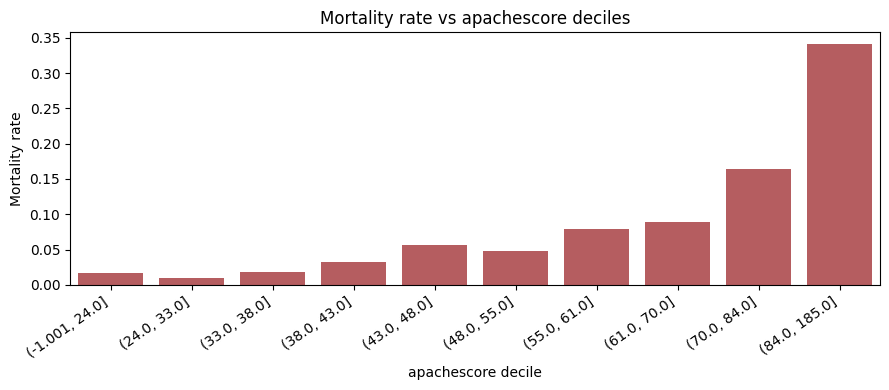

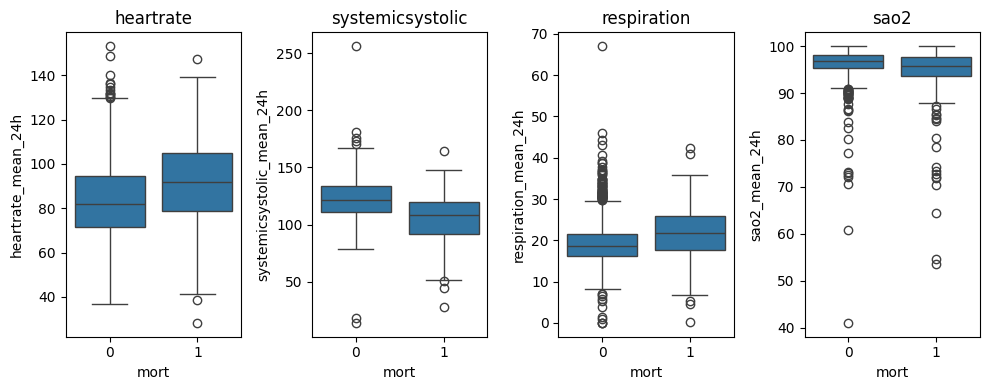

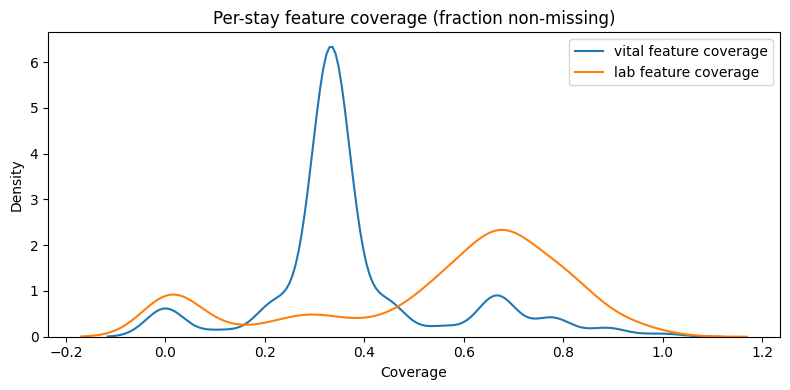

count    2520.000000
mean        0.375873
std         0.184665
min         0.000000
25%         0.333333
50%         0.333333
75%         0.333333
max         1.000000
dtype: float64
count    2520.000000
mean        0.547983
std         0.269165
min         0.000000
25%         0.414365
50%         0.638122
75%         0.729282
max         1.000000
dtype: float64


In [9]:
# Digital-twin oriented EDA: outcome patterns + quick feature sanity + similarity-ready preprocessing hints
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use model_df built previously
assert 'model_df' in globals()

dt_df = model_df.copy()

# Simple calibration-style: mortality vs APACHE if present
apache_cols = [c for c in dt_df.columns if 'apache' in c.lower()]
print(apache_cols[:30])

score_candidates = [c for c in dt_df.columns if c.lower() in ['apachescore','apacheii','apacheiv','apachescore_'] or 'apachescore' in c.lower()]
print(score_candidates)

# Pick a common one if exists
apache_score_col = None
for cand in ['apachescore','apacheivscore','apacheiiscore','apacheiv']:
    if cand in dt_df.columns:
        apache_score_col = cand
        break

if apache_score_col is not None:
    dt_df[apache_score_col] = pd.to_numeric(dt_df[apache_score_col], errors='coerce')
    tmp = dt_df[[apache_score_col,'y_hosp_mortality']].dropna()
    tmp['score_bin'] = pd.qcut(tmp[apache_score_col], q=10, duplicates='drop')
    bin_mort = tmp.groupby('score_bin', observed=True)['y_hosp_mortality'].mean().reset_index()
    plt.figure(figsize=(9,4))
    sns.barplot(data=bin_mort, x='score_bin', y='y_hosp_mortality', color='#C44E52')
    plt.title('Mortality rate vs ' + apache_score_col + ' deciles')
    plt.xlabel(apache_score_col + ' decile')
    plt.ylabel('Mortality rate')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

# Vitals: compare survivors vs non-survivors for a few robust variables
compare_cols = ['heartrate_mean_24h','systemicsystolic_mean_24h','respiration_mean_24h','sao2_mean_24h','shock_index_mean_24h']
compare_cols = [c for c in compare_cols if c in dt_df.columns]

plot_df = dt_df[compare_cols + ['y_hosp_mortality']].copy()
for c in compare_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

plt.figure(figsize=(10,4))
for idx, col in enumerate(compare_cols[:4]):
    plt.subplot(1,4,idx+1)
    sns.boxplot(data=plot_df, x='y_hosp_mortality', y=col)
    plt.xlabel('mort')
    plt.title(col.replace('_mean_24h',''))
plt.tight_layout()
plt.show()

# Quick similarity readiness: compute coverage per stay for vitals and labs
vital_feature_cols = [c for c in dt_df.columns if c.endswith('_24h') and any(v in c for v in ['temperature','heartrate','respiration','sao2','systemicsystolic','systemicdiastolic','systemicmean','cvp','etco2'])]
lab_feature_cols = [c for c in dt_df.columns if c.endswith('_24h') and c not in vital_feature_cols]

vital_coverage = dt_df[vital_feature_cols].notna().mean(axis=1)
lab_coverage = dt_df[lab_feature_cols].notna().mean(axis=1)

plt.figure(figsize=(8,4))
sns.kdeplot(vital_coverage, label='vital feature coverage')
sns.kdeplot(lab_coverage, label='lab feature coverage')
plt.title('Per-stay feature coverage (fraction non-missing)')
plt.xlabel('Coverage')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

print(vital_coverage.describe())
print(lab_coverage.describe())

What I did (and what we have now)
I engineered a first-24-hours feature set from the eICU demo time-series tables so we can use it for things like patient similarity / “digital twin” matching, risk modeling, or cohort profiling.

Concretely, I built a single wide table model_df at the ICU stay level (patientunitstayid) by merging:

1) First-24h vitals summary (vitalPeriodic)
I filtered vitalPeriodic to observationoffset in [0, 1440] minutes and computed, for each stay and each vital:

mean, std, min, max, median for
temperature, sao2, heartrate, respiration, systemicsystolic, systemicdiastolic, systemicmean, cvp, etco2

Then I added a simple derived instability feature:

shock_index_mean_24h = heartrate_mean_24h / systemicsystolic_mean_24h

2) First-24h labs summary (lab)
I filtered lab to labresultoffset in [0, 1440] and kept only the 30 most common labnames (to keep the pivot manageable). For each stay+labname I computed:

mean, min, max, std, median, count

Then pivoted wide so each stay has columns like:

mean_creatinine_24h, max_lactate_24h, etc. (naming depends on the top labnames present)
3) Joined onto your cohort
Merged these onto cohort_df (which includes y_hosp_mortality) and also parsed age into age_num when possible.

Resulting shape:

model_df.shape = (2520, 250)
So we now have 2520 stays with ~250 columns (cohort variables + engineered vitals/labs summaries).

Key findings from the engineered dataset
A) Missingness is very high for some vital channels
The biggest gaps were:

etco2_*_24h missing ~96%
temperature_*_24h missing ~94%
several lab std features are missing > 90% (because many labs are measured once or twice, so std can’t be computed)
This is totally normal in ICU data; it just means for similarity and modeling you’ll want to either:

use presence-aware distance metrics
impute carefully (or drop ultra-sparse channels like ETCO2)
B) APACHE score behaves as expected
Your cohort includes apachescore, and when I binned it into deciles, mortality increased with higher APACHE deciles (good sanity check that the cohort + label is coherent).

C) “Similarity readiness”: coverage distributions
I computed per-stay “coverage” (fraction non-missing):

vitals feature coverage mean ≈ 0.376 (median ≈ 0.333)
lab feature coverage mean ≈ 0.548 (median ≈ 0.638)
Interpretation: vitals in this table are sparser than you might expect (because not all vitals are charted in vitalPeriodic for all units / all times), while labs among the top-30 are relatively better-covered.

Where this sets us up next (digital twin use-case)
At this point, model_df is ready for:

building a patient similarity index (e.g., standardized features + cosine distance / Gower-like distance handling missingness)
nearest-neighbor “digital twin” matching for a given index stay
training a baseline mortality model to define “clinical state embeddings” (then do similarity in embedding space)
If you tell me your exact digital-twin goal (e.g., match on physiology only, match on labs + vitals, exclude treatment variables, time-series similarity rather than 24h summary), I’ll lock the preprocessing choices and build the actual matching pipeline.




In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import pandas as pd

# Define target variable y
y = model_df['y_hosp_mortality']

# Define features X by dropping identifier and target columns
feature_cols = [col for col in model_df.columns if col not in ['patientunitstayid', 'y_hosp_mortality', 'uniquepid', 'hospitalid', 'hospitaldischargestatus', 'age']]
X = model_df[feature_cols].copy()

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Impute missing numerical values in X with the median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

# Train the RandomForestClassifier model
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(X, y)

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(20))

actualhospitalmortality_EXPIRED    0.110915
unitdischargestatus_Expired        0.081873
unitdischargelocation_Death        0.053293
apachescore                        0.014753
predictedhospitalmortality         0.012794
sao2_std_24h                       0.011654
sao2_min_24h                       0.009994
heartrate_std_24h                  0.009338
age_num                            0.007244
predictediculos                    0.006972
sao2_mean_24h                      0.006887
respiration_mean_24h               0.006870
max_ph_24h                         0.006730
sao2_median_24h                    0.005997
heartrate_min_24h                  0.005945
median_bun_24h                     0.005626
heartrate_mean_24h                 0.005580
heartrate_median_24h               0.005526
respiration_median_24h             0.005514
mean_wbc_x_1000_24h                0.005287
dtype: float64


In [13]:
corr = model_df.corr(numeric_only=True)['y_hosp_mortality'].abs().sort_values(ascending=False)
print(corr.head(20))

y_hosp_mortality               1.000000
apachescore                    0.356722
acutephysiologyscore           0.330637
systemicsystolic_median_24h    0.295189
systemicsystolic_mean_24h      0.293044
predictediculos                0.264748
shock_index_mean_24h           0.214426
median_ph_24h                  0.211138
sao2_min_24h                   0.210162
mean_ph_24h                    0.209153
cvp_std_24h                    0.202041
heartrate_std_24h              0.201994
systemicsystolic_min_24h       0.199237
min_ph_24h                     0.193014
sao2_mean_24h                  0.185855
median_anion_gap_24h           0.185464
mean_anion_gap_24h             0.184779
max_anion_gap_24h              0.183127
max_ph_24h                     0.181527
sao2_std_24h                   0.172842
Name: y_hosp_mortality, dtype: float64


In [14]:
missing_impact = model_df.isnull().mean().sort_values(ascending=False)

In [16]:
# Remove high missing
threshold = 0.9
model_df = model_df.loc[:, model_df.isnull().mean() < threshold].copy()

# Define target variable y
y = model_df['y_hosp_mortality']

# Define features X by dropping identifier and target columns
# The original 'age' column might still be an object type, so we exclude it and rely on 'age_num'.
# 'hospitaldischargestatus' is also often a string and a direct outcome, so it's excluded from features.
exclude_cols = ['patientunitstayid', 'y_hosp_mortality', 'uniquepid', 'hospitalid', 'age']
if 'hospitaldischargestatus' in model_df.columns:
    exclude_cols.append('hospitaldischargestatus')

feature_cols = [col for col in model_df.columns if col not in exclude_cols]
X = model_df[feature_cols].copy()

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Impute missing numerical values in X with the median
# Using SimpleImputer for consistency and robustness
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)


# Train model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42) # Add random_state for reproducibility
rf.fit(X, y)

# Get importance
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Select top 50
top_features = importances.sort_values(ascending=False).head(50).index

X_selected = X[top_features]

In [17]:
from sklearn.model_selection import cross_val_score

score_full = cross_val_score(rf, X, y, cv=5).mean()
score_selected = cross_val_score(rf, X_selected, y, cv=5).mean()

print(score_full, score_selected)

0.9591269841269842 0.986111111111111
